<a href="https://colab.research.google.com/github/sandeepProject/Online-Book-Popularity/blob/main/notebooks/Online_Book_Popularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Machine Learning Project on <br>
###ONLINE BOOK POPULARITY PREDICTION<br>
####Dataset : Amazon.in - Book Data

Steps : <br>
1. Data scraped from Amazon.in <br>
2. Initial EDA (Exploratory Data Analysis) on raw data.<br>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Scraped Amazon Data

In [3]:
# Load data
df = pd.read_csv('/content/amazon_raw_data.csv')
print(df.head())

          ISBN-13                                              Title  \
0  978-9389931846  You Can by George Matthew Adams | The Classic ...   
1  978-1786330895  Ikigai: The Japanese secret to a long and happ...   
2  978-8172345136                                      Metamorphosis   
3  978-9395970334                            The Psychology of Money   
4  978-1760630720  Courage To Be Disliked, The: How to free yours...   

                             Author Sales Price   MRP  Rating  Review Count  \
0              George Matthew Adams         94.  ₹149     4.4          7444   
1                     Héctor García        148.  ₹550     4.6         61957   
2                       Franz Kafka         94.  ₹129     4.4         16312   
3                     Morgan Housel        491.  ₹399     4.6         80778   
4  Ichiro Kishimi and Fumitake Koga        499.  ₹550     4.5         21835   

     Binding            Published Date  Publication Date  Pages Language  \
0  Paperback   B

In [4]:
# Basic Inspection

print("Shape :", df.shape)
print("---Data Types and Non-Null Count---")
print(df.info())
print("---Descriptive Statistics---")
print(df.describe())

Shape : (3428, 19)
---Data Types and Non-Null Count---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3428 entries, 0 to 3427
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ISBN-13            2479 non-null   object 
 1   Title              3428 non-null   object 
 2   Author             3394 non-null   object 
 3   Sales Price        3427 non-null   object 
 4   MRP                3174 non-null   object 
 5   Rating             2774 non-null   float64
 6   Review Count       3428 non-null   int64  
 7   Binding            3422 non-null   object 
 8   Published Date     3228 non-null   object 
 9   Publication Date   3393 non-null   object 
 10  Pages              3428 non-null   int64  
 11  Language           3428 non-null   object 
 12  Best Sellers Rank  2944 non-null   float64
 13  Genre              2944 non-null   object 
 14  5-Star %           3428 non-null   object 
 15  4-Star %         

In [7]:
from pandas._libs import missing
# Missing values analysis

# print("---Missing Values---")
# print(df.isnull().sum())
missing_total = df.isnull().sum()
missing_percent = (missing_total/len(df))*100
missing_table = pd.concat([missing_total, missing_percent], axis=1, keys=['Total', 'Percentage'])
print("---Missing Values Report---")
#print(missing_table)
print(missing_table[missing_table['Total'] > 0].sort_values(by='Total', ascending=False))
#

---Missing Values Report---
                   Total  Percentage
ISBN-13              949   27.683781
Rating               654   19.078180
Best Sellers Rank    484   14.119020
Genre                484   14.119020
MRP                  254    7.409568
Published Date       200    5.834306
Publication Date      35    1.021004
Author                34    0.991832
Binding                6    0.175029
Sales Price            1    0.029172


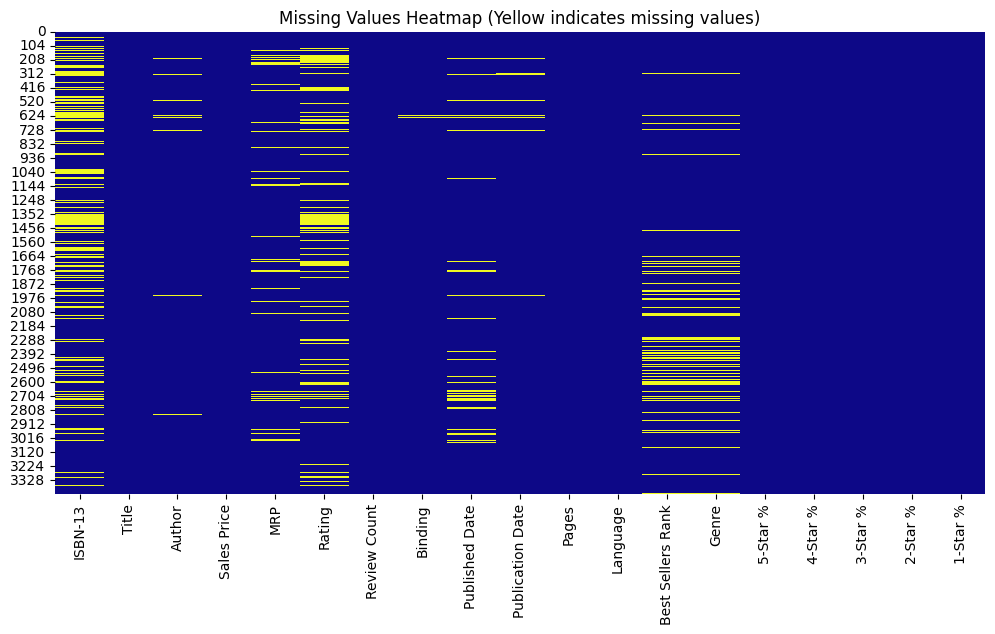

In [16]:
# Visualize Missing values using Heatmap

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap='plasma', cbar=False)
plt.title('Missing Values Heatmap (Yellow indicates missing values)')
plt.show()

In [18]:
# Duplicate check

print("---Duplicate Values---")
print(f"\n No: of Rows : {df.duplicated().sum()}")

---Duplicate Values---

 No: of Rows : 202


In [19]:
# Basic Cleaning for visuals (required for EDA)

def clean_numeric(val):
  if pd.isna(val): return np.nan
  val = str(val).replace('₹', '').strip('.')
  try:
    return float(val)
  except:
    return np.nan

In [21]:
df['Clean_SalesPrice'] = df['Sales Price'].apply(clean_numeric)

In [23]:
df['Clean_SalesPrice'].head()

,Clean_SalesPrice
0,94.0
1,148.0
2,94.0
3,491.0
4,499.0


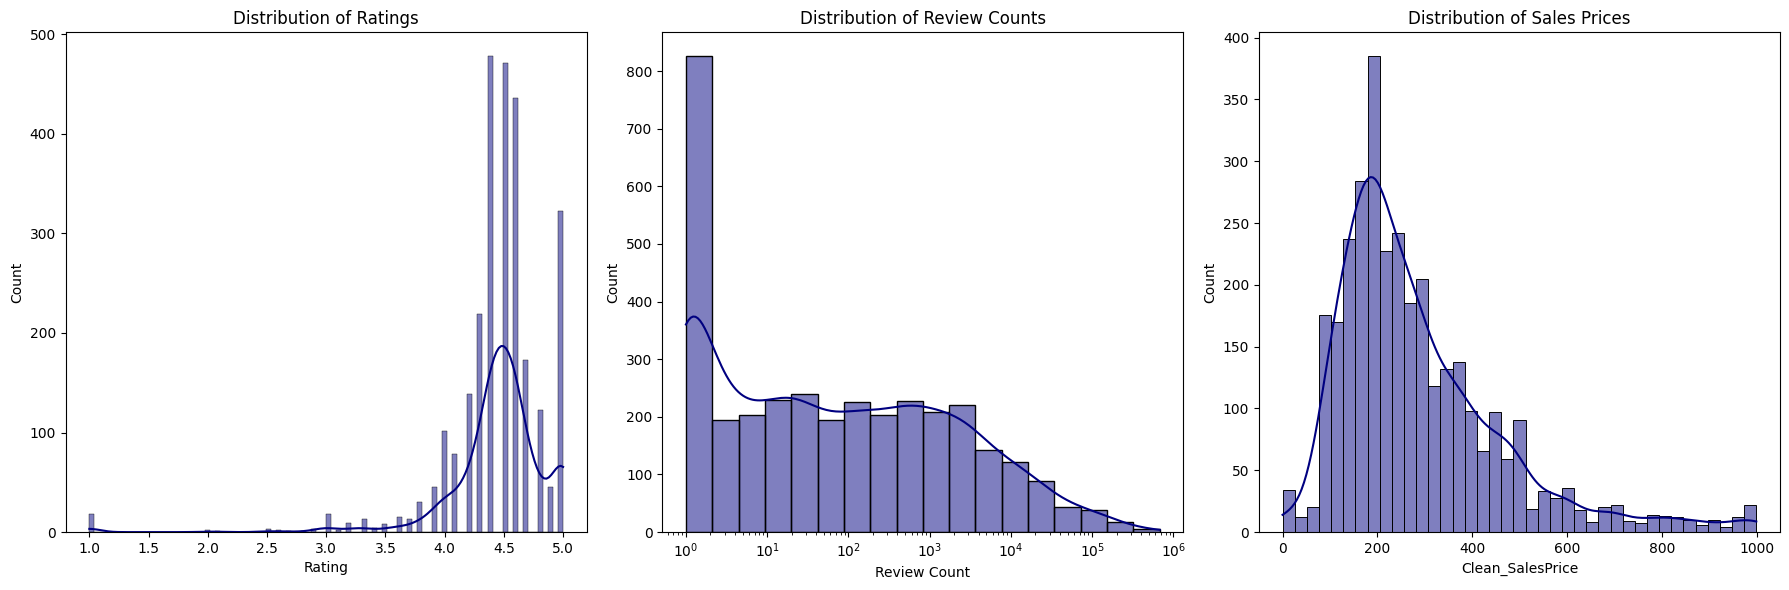

In [28]:
# Distribution of (Rating, Review count, Price Distribution)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Rating
sns.histplot(df['Rating'].dropna(), kde=True, ax=axs[0], color='#000080')
axs[0].set_title('Distribution of Ratings')

# Review Count
# used Log scale for readability
sns.histplot(df['Review Count']+1, kde=True, ax=axs[1], log_scale=True, color='#000080')
axs[1].set_title('Distribution of Review Counts')

# Sales Price
sns.histplot(df['Clean_SalesPrice'].dropna(), kde=True, ax=axs[2], color='#000080')
axs[2].set_title('Distribution of Sales Prices')

plt.tight_layout()
plt.show()

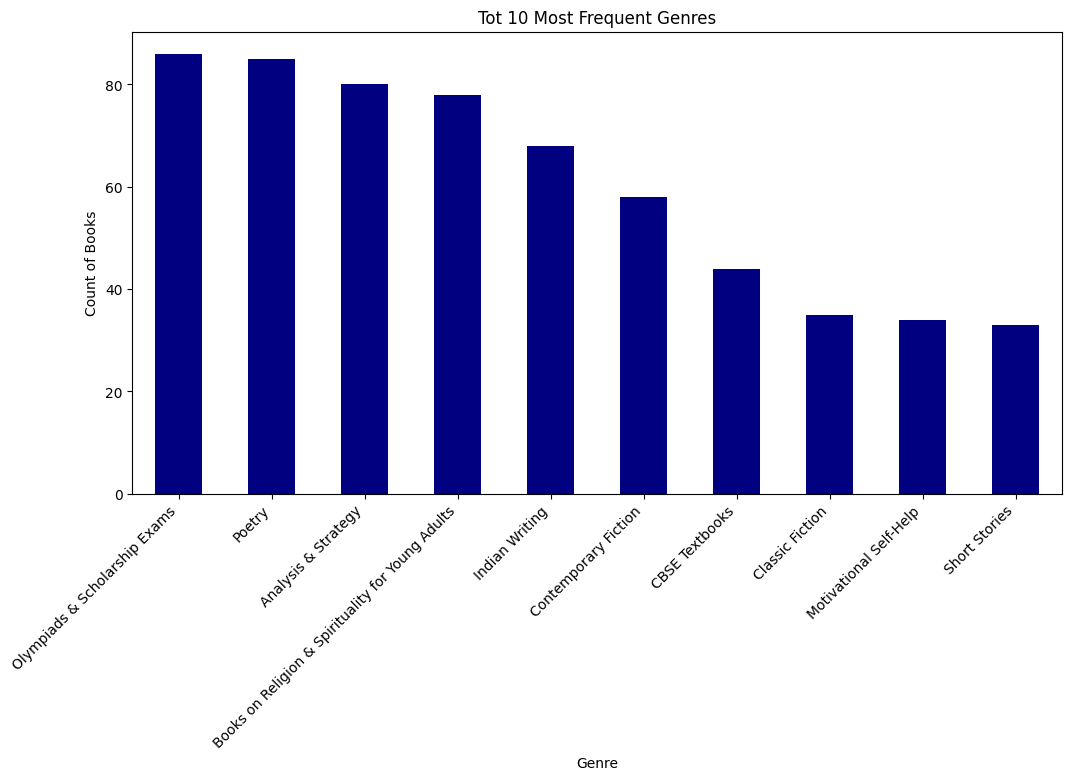

In [34]:
# Categprical analysis

plt.figure(figsize=(12, 6))
df['Genre'].value_counts().head(10).plot(kind='bar', color='#000080')
plt.title('Tot 10 Most Frequent Genres')
plt.xlabel('Genre')
plt.ylabel('Count of Books')
plt.xticks(rotation=45, ha='right')
plt.show()

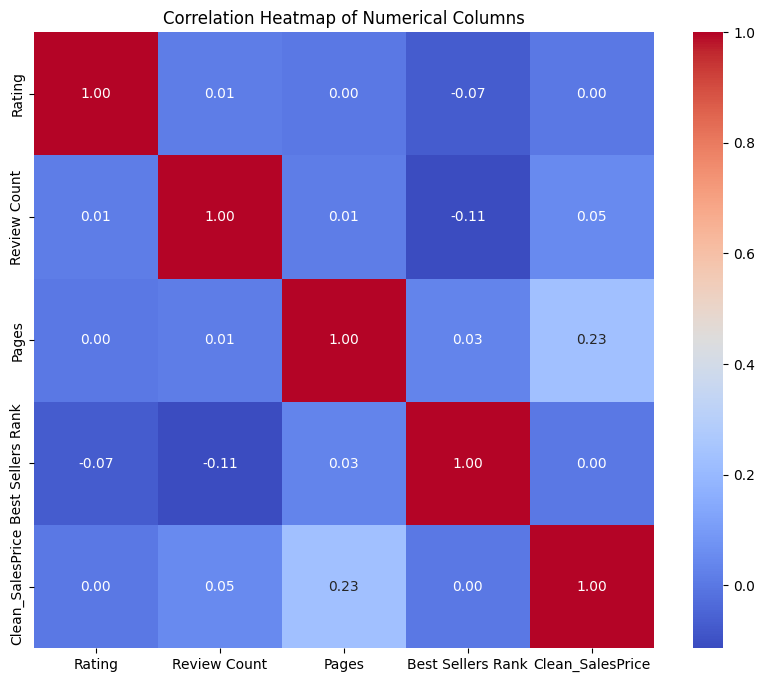

In [35]:
# Correlation Heatmap (Relationships)

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

In [38]:
# Unique Categorical Data

unique_authors = df['Author'].nunique()
unique_genres = df['Genre'].nunique()
unique_rating = df['Rating'].nunique()
unique_binding = df['Binding'].nunique()
unique_language = df['Language'].nunique()

print(f"Unique Authors: {unique_authors}")
print(f"Unique Genres: {unique_genres}")
print(f"Unique Ratings: {unique_rating}")
print(f"Unique Bindings: {unique_binding}")
print(f"Unique Languages: {unique_language}")

Unique Authors: 1687
Unique Genres: 598
Unique Ratings: 29
Unique Bindings: 29
Unique Languages: 47


In [41]:
# Unique Author List

raw_unique = df['Author'].dropna().unique()
raw_unique.sort()

# Print all
for author in raw_unique:
    print(author)

.ARU. RAMANATHAN
3H Learning
99U
A P J Abdul Kalam
A.C. BHAKTIVEDANTA SWAMI PRABHUPADA
A.G. Krishnamurthy
A.P.J. Abdul Kalam
A.R.Manikanth
ACHARYA ANANTHA KRISHNA SWAMY
AJAY PATEL
AL.Muthu
ALLEN Expert Faculties
AMRITA BHARATI
ANANT PAI
ANIL AHLAWAT
ANIL GAUTAM
ANJNA VIRMANI
ANNIE VALLIKAPPEN
ASHFAK SHAIKH
Aakash Karkare
Aanchal Malhotra
Aarambhh M Singh
Aaranya Roy
Abeer Verma
Abhik Mitra
Abhinav Shrivastava
Abhinay Sharma
Abhishek Kumar
Abhishek Publication
Abhishek Raaj Gupta
Abhishek Shukla
Abhishek Singh
Abhishek Srivastava Sir
Abis
Aced It Publications
Acharya Chatursen
Acharya Ekkirala Bharadwaja
Acharya Pandit Shivdutt Mishr Shastri O.
Acharya Prashant
Acharya Yatendra
Achyut Godbole
Adam Grant
Adda247 Publications
Aditi Chatterjee
Aditi Patel
Aditi Rana
Aditya Arora
Aditya Nighhot
Aditya Rahbar
Aditya Ranjan Sir
Aditya Srivastava
Aditya Yadav
Agatha Christie
Agatha Christie Ltd
Ajay K Pandey
Ajeesh Ashokan
Ajitkumar
Akanksha Singh
Akash Gola
Akash Sandhya Nema
Akshat Gupta
Aks

In [55]:
# Unique Rating List
raw_unique_ratings = df['Rating'].dropna().unique()
raw_unique_ratings.sort()

# Print all
for ratings in raw_unique_ratings:
    print(ratings)

1.0
2.0
2.1
2.5
2.6
2.7
2.8
2.9
3.0
3.1
3.2
3.3
3.4
3.5
3.6
3.7
3.8
3.9
4.0
4.1
4.2
4.3
4.4
4.5
4.6
4.7
4.8
4.9
5.0


In [56]:
# Unique Language List

raw_unique_lang = df['Language'].dropna().unique()
raw_unique_lang.sort()

# Print all
for lang in raw_unique_lang:
    print(lang)

(Ch. 1) are organised around discrete grammar rules, each reinforced with identification and transformation exercises
,
: Perfect for young readers to read independently or for parents to read aloud during story time or festivals.
: Written in a simple, engaging style suitable for beginners and seasoned readers alike.
Altaic Languages
Arabic
Assamese
Bengali
Bengali, Bengali
Binding:Textbook Binding
Children are encouraged to read books as it helps them improve vocabulary and communication skills.
Easy-to-understand stories that make reading enjoyable for young learners.
Easy-to-understand storytelling makes reading enjoyable for young learners.
Easy-to-understand words ensure fun, independent reading or bonding through shared storytelling.
English
English, English
English, English, English
English, Hindi
English, Tamil
Facts are explained in a simple way for quick understanding and retention.
German
Gujarati
Gujarati, Gujarati
Hindi
Hindi, Hindi
Kannada
Listening to and reading storie